<a href="https://colab.research.google.com/github/beziatka14/ML-sunc/blob/main/HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Кластеризация ЕГЭ (8.5 если сделаны все задачи)

Рядом лежат экселевские таблицы с координатами точек. В 3 и 4 задаче используется манхетеское расстояние. В остальных Евклидово.

* Постройте Распределение точек
* Кластеризуйте руками
* Постройте Распределение точек, отметьте принадлежность кластеров цветами
* Найдите в каждом кластере точку, расстояние от которой до всех остальных минимально
* Выведите усреднение центров всех кластеров * 1000

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [44]:
def point_distribution(df, w=14, h=10, size=70):
    plt.figure(figsize=(w, h))
    plt.title('Распределение точек')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.scatter(df['X'], df['Y'], s=size, edgecolor='black')

def point_distribution_with_cluster(dfs, colors, w=14, h=10, size=70, title='Распределение точек c кластеризацией'):
    plt.figure(figsize=(w, h))

    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    for i in range(len(dfs)):
        plt.scatter(dfs[i]['X'], dfs[i]['Y'], s=size, color=colors[i], edgecolor='black', label=f'Cluster {i + 1}')
    plt.legend()

def distance_euclid(dot1, dot2):
    return ((dot2[0] - dot1[0])**2 + (dot2[1] - dot1[1])**2)**0.5


def distance_manhattan(dot1, dot2):
    return abs(dot2[0] - dot1[0]) + abs(dot2[1] - dot1[1])


def find_cluster_center(cluster, f, inf=1000):
    x_m, y_m = 0, 0
    minim = len(cluster) * inf
    for i in range(len(cluster)):
        summa = 0
        for j in range(len(cluster)):
            summa += f(cluster[i], cluster[j])
        if minim > summa:
            minim = summa
            x_m, y_m = cluster[i][0], cluster[i][1]
    return x_m, y_m

def print_coord(x, y):
    print(f"X - {x:.5f}\nY - {y:.5f}")


## 0

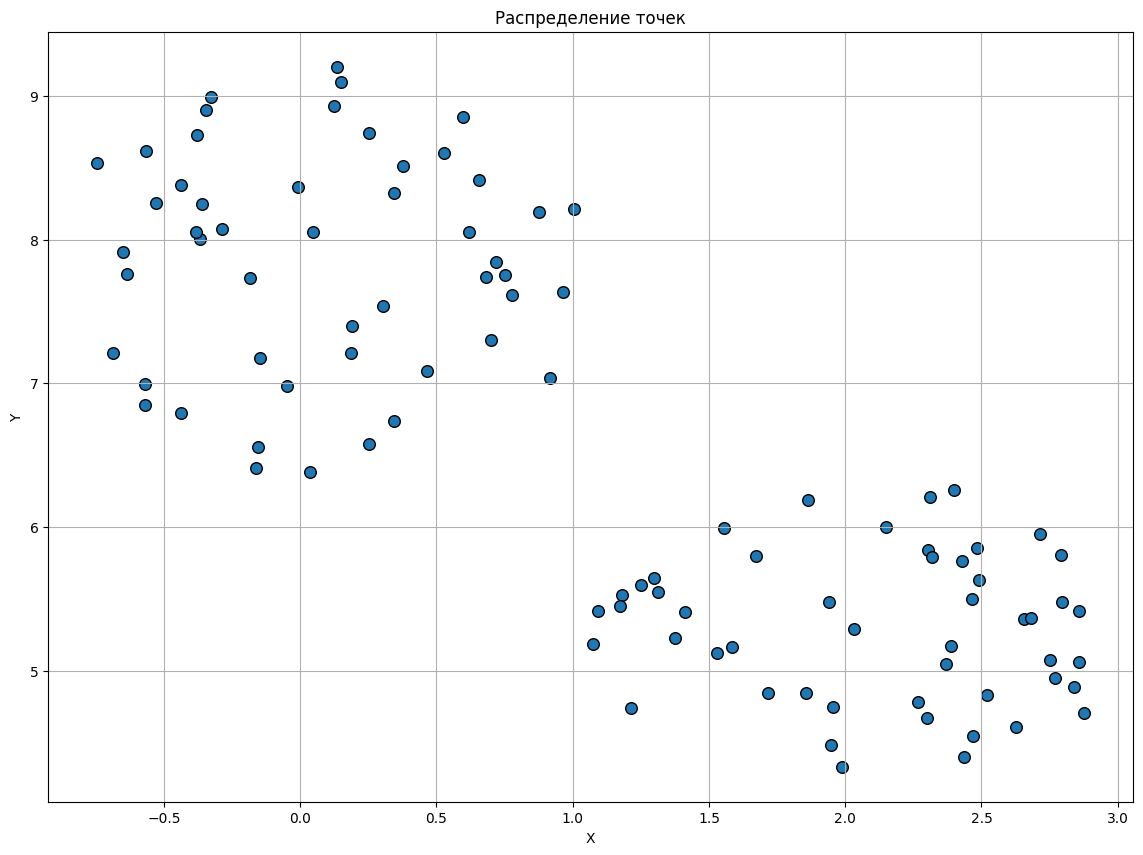

In [45]:
data = pd.read_excel('0.xls')
df = pd.DataFrame(data)

point_distribution(df)
plt.show()

In [46]:
cluster1 = []
cluster2 = []

for dot in df.values:
    if dot[0] < 1.1 and dot[1] > 6.2:
        cluster1.append(dot)
    else:
        cluster2.append(dot)

cluster1_df = pd.DataFrame(cluster1, columns=['X', 'Y'])
cluster2_df = pd.DataFrame(cluster2, columns=['X', 'Y'])

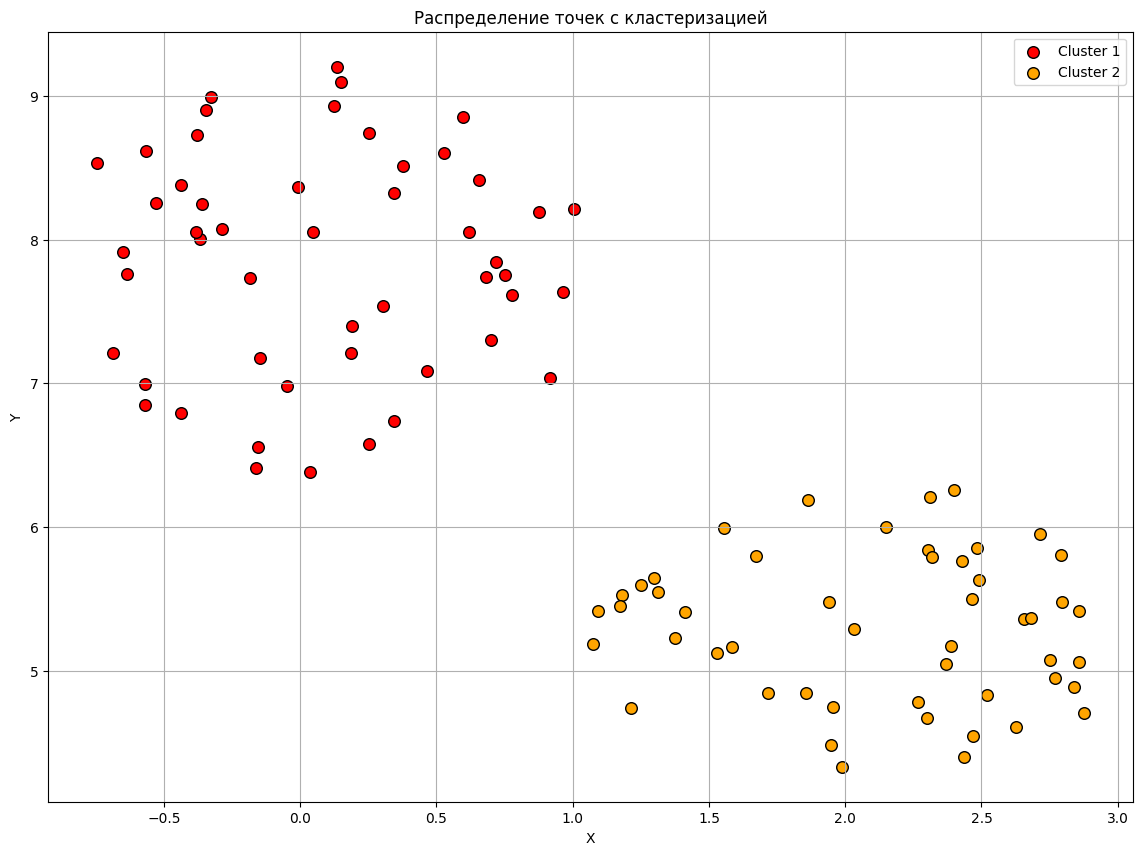

In [47]:
point_distribution_with_cluster(dfs=(cluster1_df, cluster2_df), colors=('red', 'orange'))
plt.show()

In [48]:
x_cent_1, y_cent_1 = find_cluster_center(cluster1, distance_euclid)
x_cent_2, y_cent_2 = find_cluster_center(cluster2, distance_euclid)

print("Координаты центров кластеров")
print("Кластер 1:")
print_coord(x_cent_1, y_cent_1)
print("Кластер 2:")
print_coord(x_cent_2, y_cent_2)

Координаты центров кластеров
Кластер 1:
X - 0.04811
Y - 8.05305
Кластер 2:
X - 2.03390
Y - 5.28930


In [49]:
x_mid = ((x_cent_1 + x_cent_2) / 2) * 1000
y_mid = ((y_cent_1 + y_cent_2) / 2) * 1000

print("Усредненное центров кластеров * 1000:")
print_coord(x_mid, y_mid)

Усредненное центров кластеров * 1000:
X - 1041.00628
Y - 6671.17341


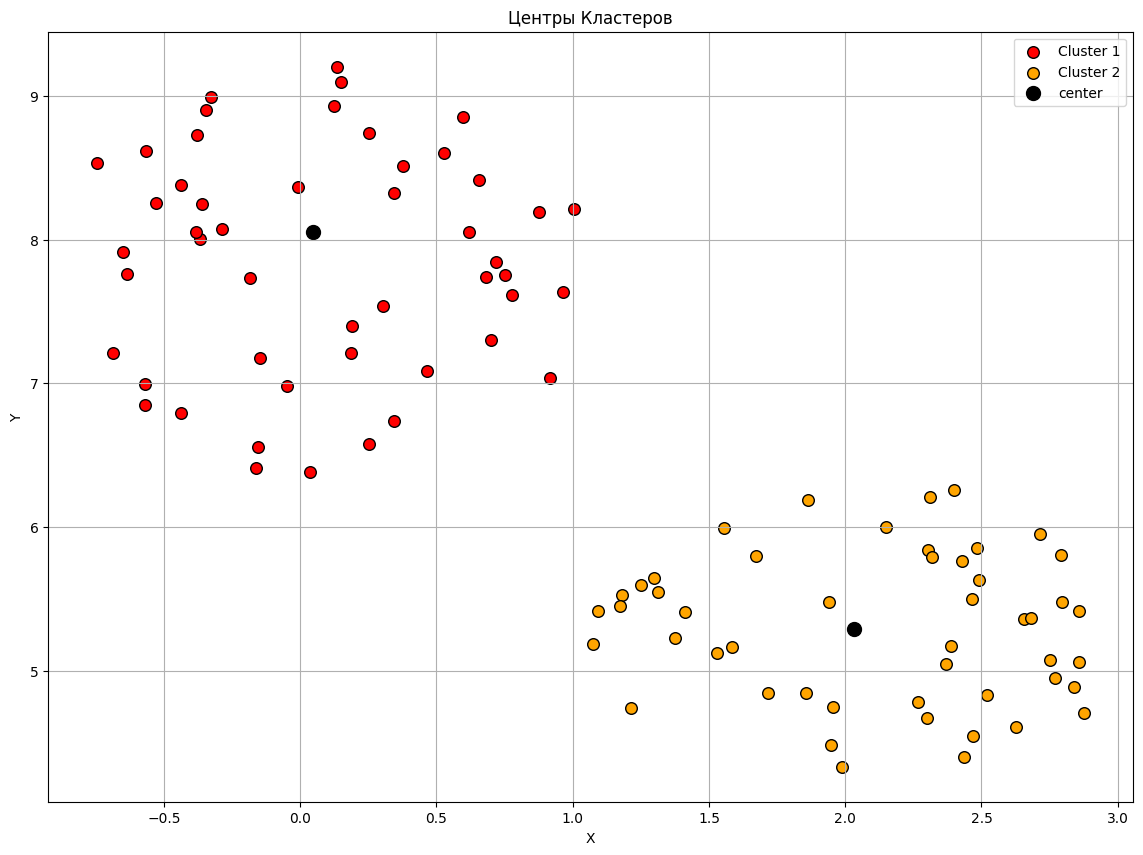

In [50]:
centers = pd.DataFrame([[x_cent_1, y_cent_1], [x_cent_2, y_cent_2]], columns=['X', 'Y'])

point_distribution_with_cluster(dfs=(cluster1_df, cluster2_df), colors=('red', 'orange'),
                                title='Центры Кластеров')
plt.scatter(centers['X'], centers['Y'], color='black', label='center', s=100)
plt.legend()

plt.show()

## 1

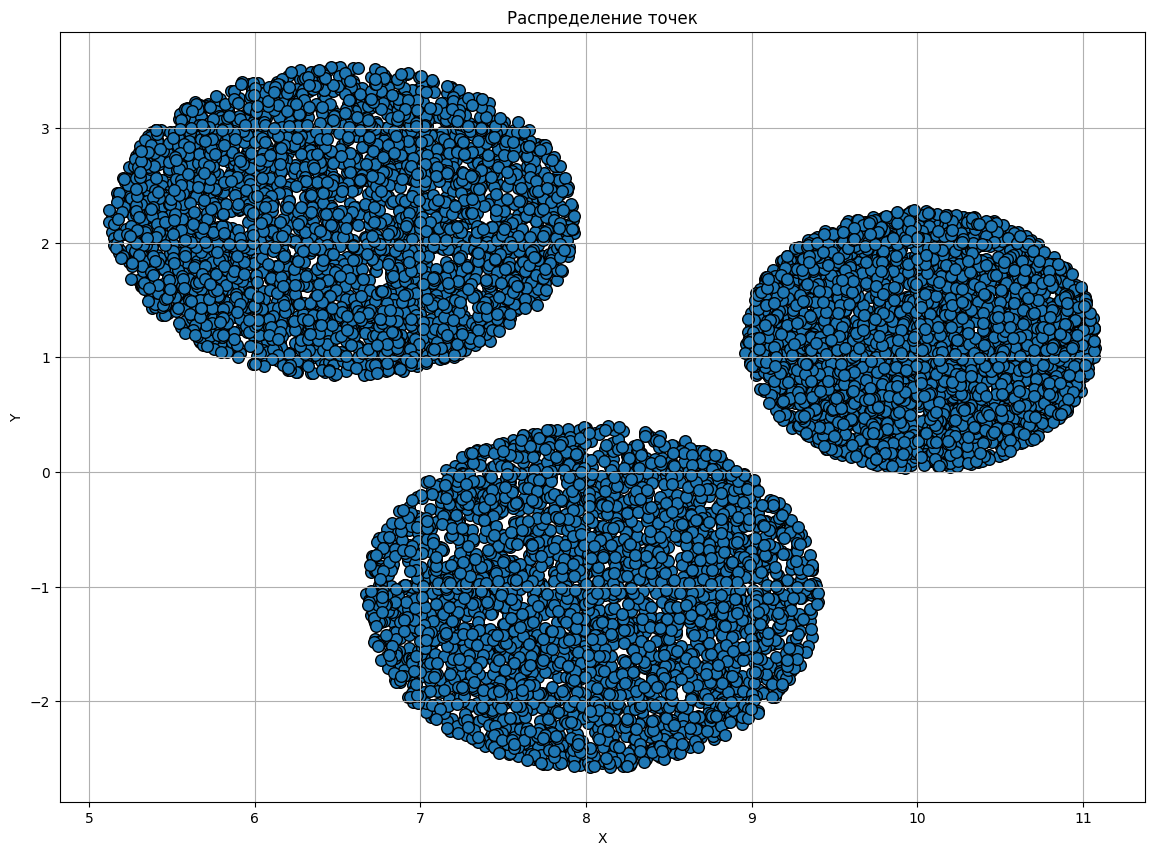

In [51]:
data = pd.read_excel('1.xls')
df = pd.DataFrame(data)

point_distribution(df)
plt.show()

In [52]:
cluster1 = []
cluster2 = []
cluster3 = []

for dot in df.values:
    if dot[0] < 8 and dot[1] > 0.6:
        cluster1.append(dot)
    elif dot[1] < -1.25 * dot[0] + 11.5:
        cluster2.append(dot)
    else:
        cluster3.append(dot)

cluster1_df = pd.DataFrame(cluster1, columns=['X', 'Y'])
cluster2_df = pd.DataFrame(cluster2, columns=['X', 'Y'])
cluster3_df = pd.DataFrame(cluster3, columns=['X', 'Y'])

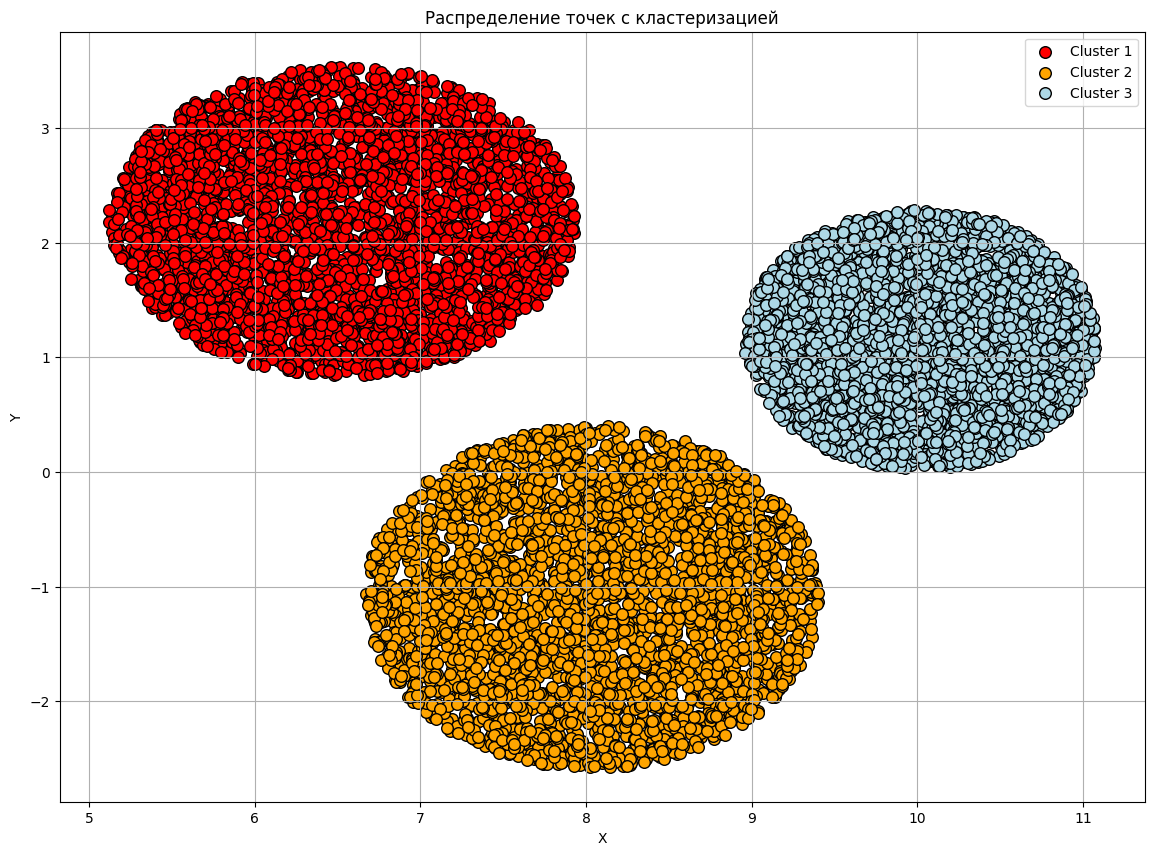

In [53]:
point_distribution_with_cluster(dfs=(cluster1_df, cluster2_df, cluster3_df), colors=('red', 'orange', 'lightblue'))
plt.show()

In [54]:
x_cent_1, y_cent_1 = find_cluster_center(cluster1, distance_euclid)
x_cent_2, y_cent_2 = find_cluster_center(cluster2, distance_euclid)
x_cent_3, y_cent_3 = find_cluster_center(cluster3, distance_euclid)

print("Координаты центров кластеров")
print("Кластер 1:")
print_coord(x_cent_1, y_cent_1)
print("Кластер 2:")
print_coord(x_cent_2, y_cent_2)
print("Кластер 3:")
print_coord(x_cent_3, y_cent_3)

Координаты центров кластеров
Кластер 1:
X - 6.46998
Y - 2.16976
Кластер 2:
X - 8.04007
Y - -1.10871
Кластер 3:
X - 10.02254
Y - 1.15420


In [55]:
x_mid = ((x_cent_1 + x_cent_2 + x_cent_3) / 3) * 1000
y_mid = ((y_cent_1 + y_cent_2 + x_cent_3) / 3) * 1000

print("Усредненное центров кластеров * 1000:")
print_coord(x_mid, y_mid)

Усредненное центров кластеров * 1000:
X - 8177.53081
Y - 3694.53025


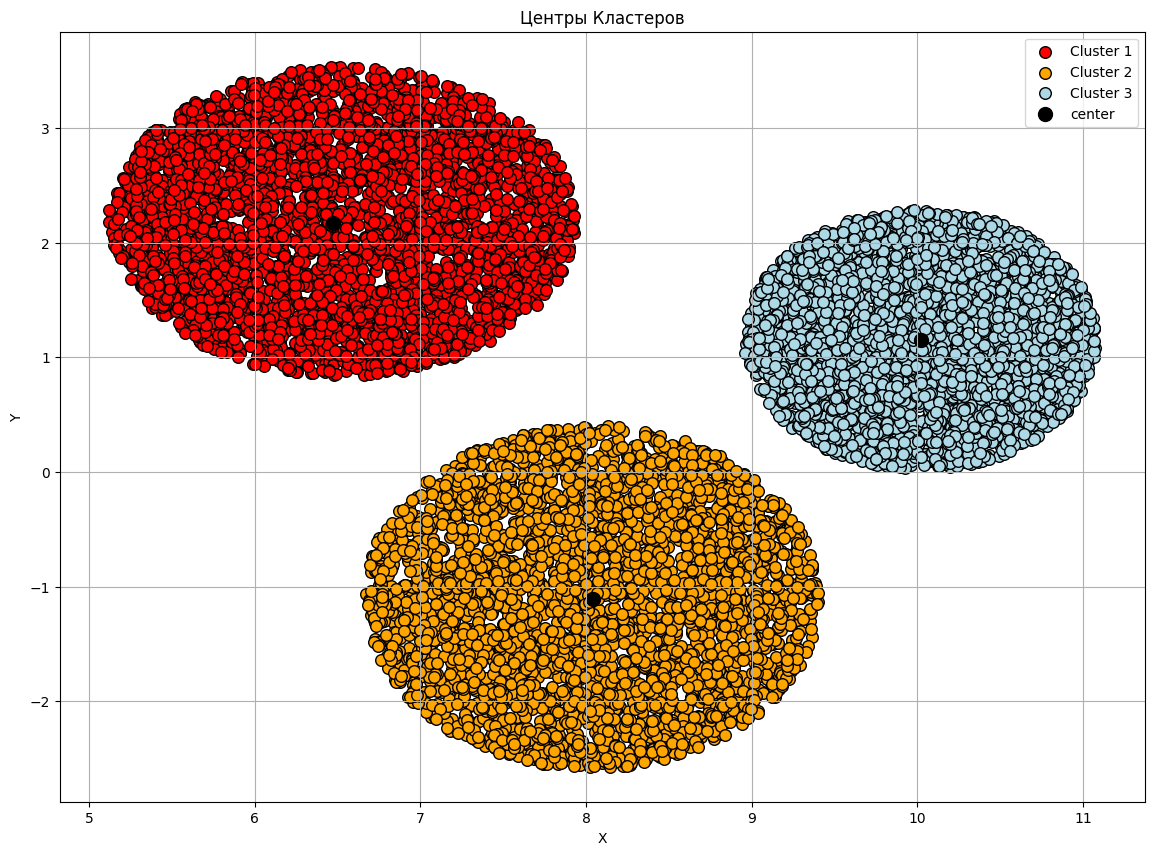

In [56]:
centers = pd.DataFrame([[x_cent_1, y_cent_1], [x_cent_2, y_cent_2], [x_cent_3, y_cent_3]], columns=['X', 'Y'])

point_distribution_with_cluster(dfs=(cluster1_df, cluster2_df, cluster3_df), colors=('red', 'orange', 'lightblue'),
                                title='Центры Кластеров')
plt.scatter(centers['X'], centers['Y'], color='black', label='center', s=100)
plt.legend()

plt.show()

## 2

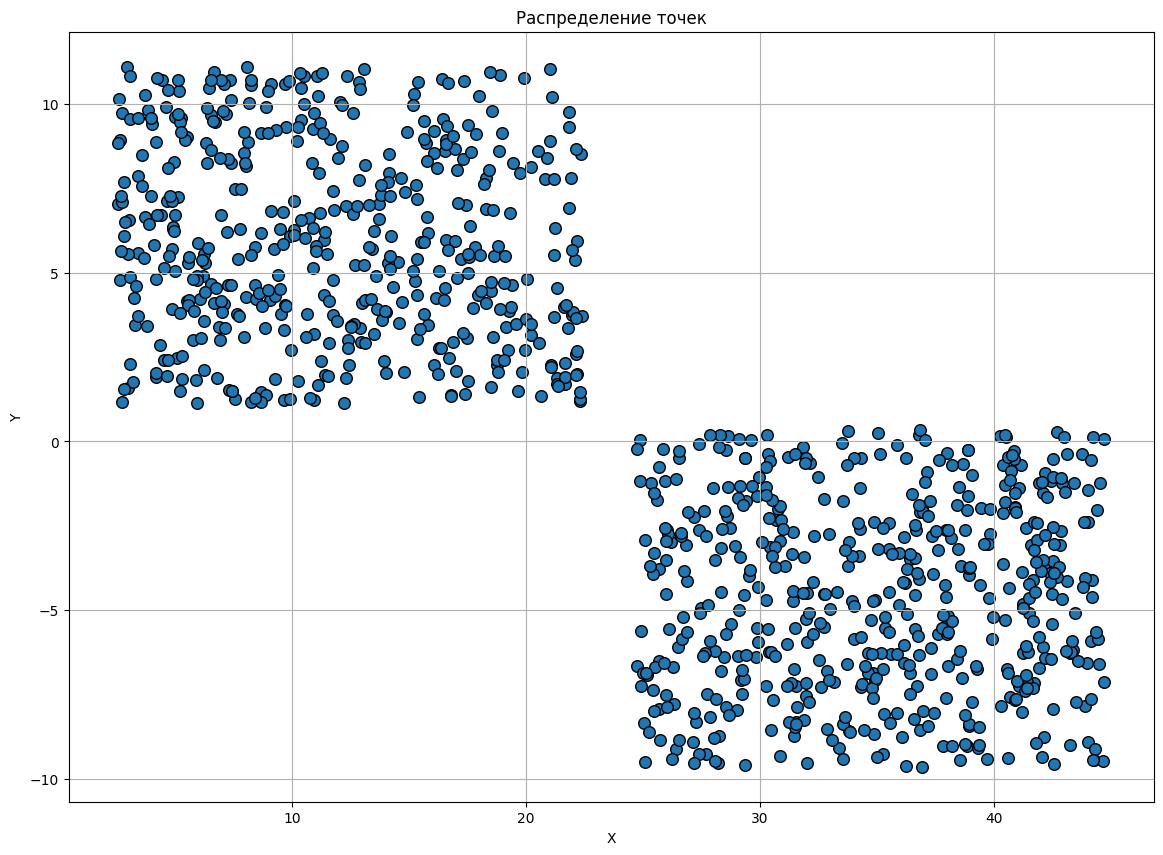

In [79]:
data = pd.read_excel('2.xlsx', header=None)
data.columns = ['X', 'Y']
df = pd.DataFrame(data)

point_distribution(df)
plt.show()

In [80]:
cluster1 = []
cluster2 = []

for dot in df.values:
    if dot[0] < 23 and dot[1] > 0.5:
        cluster1.append(dot)
    else:
        cluster2.append(dot)

cluster1_df = pd.DataFrame(cluster1, columns=['X', 'Y'])
cluster2_df = pd.DataFrame(cluster2, columns=['X', 'Y'])

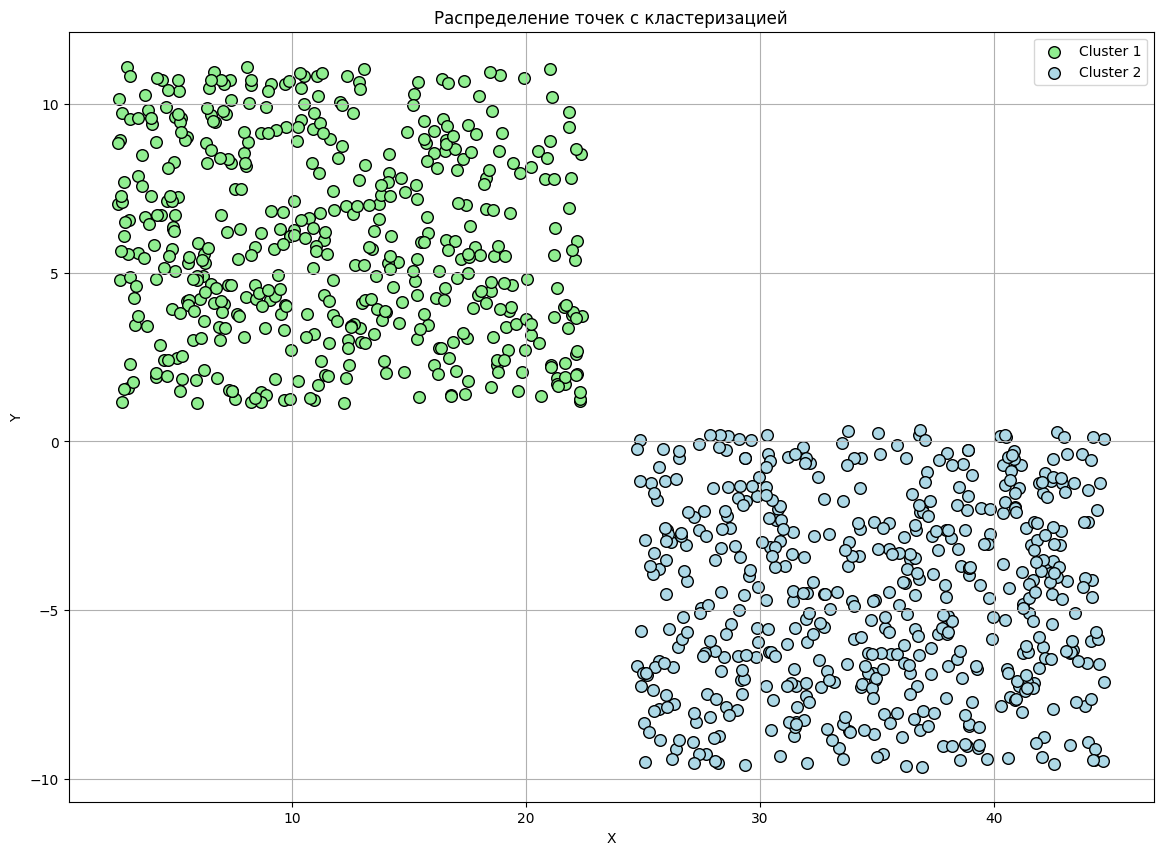

In [81]:
point_distribution_with_cluster(dfs=(cluster1_df, cluster2_df), colors=('lightgreen', 'lightblue'))
plt.show()

In [82]:
x_cent_1, y_cent_1 = find_cluster_center(cluster1, distance_euclid)
x_cent_2, y_cent_2 = find_cluster_center(cluster2, distance_euclid)

print("Координаты центров кластеров")
print("Кластер 1:")
print_coord(x_cent_1, y_cent_1)
print("Кластер 2:")
print_coord(x_cent_2, y_cent_2)

Координаты центров кластеров
Кластер 1:
X - 11.33408
Y - 5.96596
Кластер 2:
X - 34.92635
Y - -4.69528


In [84]:
x_mid = ((x_cent_1 + x_cent_2) / 2) * 1000
y_mid = ((y_cent_1 + y_cent_2) / 2) * 1000

print("Усредненное центров кластеров * 1000:")
print_coord(x_mid, y_mid)

Усредненное центров кластеров * 1000:
X - 23130.21576
Y - 635.34229


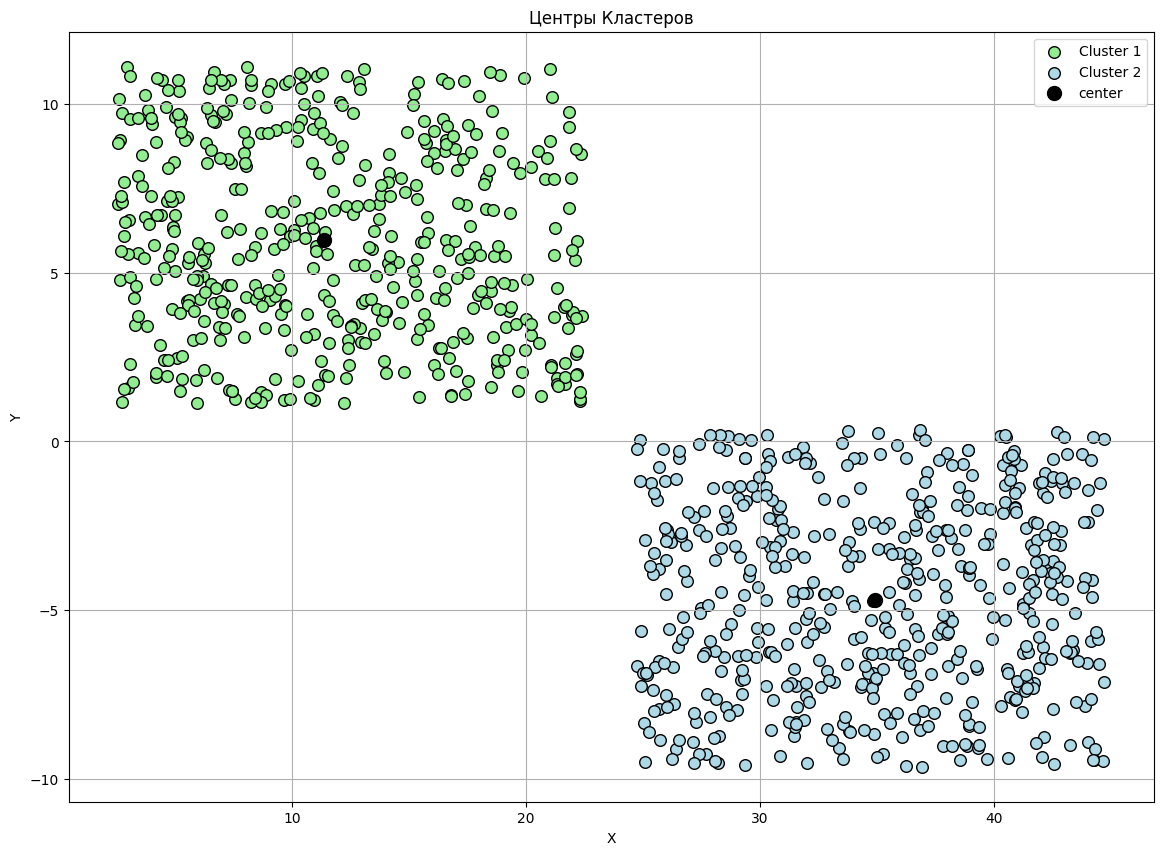

In [85]:
centers = pd.DataFrame([[x_cent_1, y_cent_1], [x_cent_2, y_cent_2]], columns=['X', 'Y'])

point_distribution_with_cluster(dfs=(cluster1_df, cluster2_df), colors=('lightgreen', 'lightblue'),
                                title='Центры Кластеров')
plt.scatter(centers['X'], centers['Y'], color='black', label='center', s=100)
plt.legend()

plt.show()

## 3

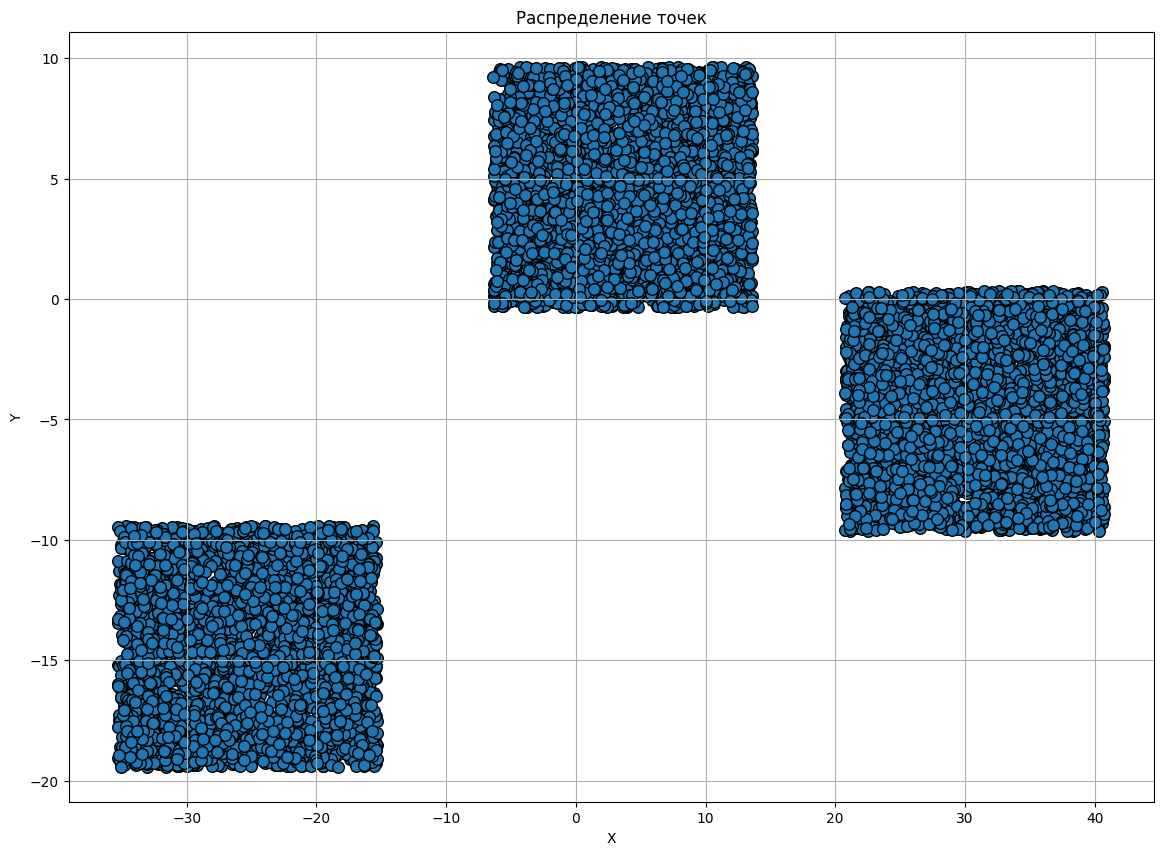

In [86]:
data = pd.read_excel('3.xlsx', header=None)
data.columns = ['X', 'Y']
df = pd.DataFrame(data)

point_distribution(df)
plt.show()

In [87]:
cluster1 = []
cluster2 = []
cluster3 = []

for dot in df.values:
    if dot[0] < -10:
        cluster1.append(dot)
    elif dot[0] < 17:
        cluster2.append(dot)
    else:
        cluster3.append(dot)

cluster1_df = pd.DataFrame(cluster1, columns=['X', 'Y'])
cluster2_df = pd.DataFrame(cluster2, columns=['X', 'Y'])
cluster3_df = pd.DataFrame(cluster3, columns=['X', 'Y'])

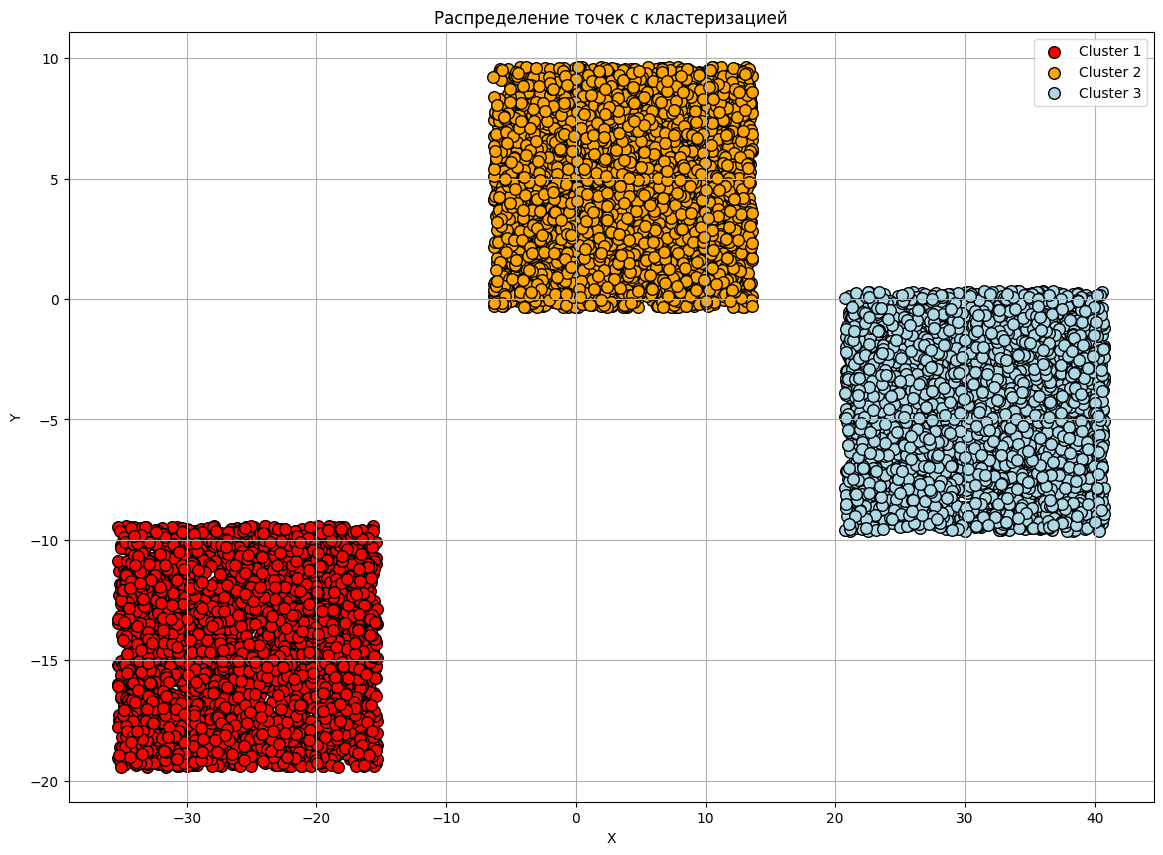

In [88]:
point_distribution_with_cluster(dfs=(cluster1_df, cluster2_df, cluster3_df), colors=('red', 'orange', 'lightblue'))
plt.show()

In [93]:
x_cent_1, y_cent_1 = find_cluster_center(cluster1, distance_manhattan)
x_cent_2, y_cent_2 = find_cluster_center(cluster2, distance_manhattan)
x_cent_3, y_cent_3 = find_cluster_center(cluster3, distance_manhattan)

print("Координаты центров кластеров")
print("Кластер 1:")
print_coord(x_cent_1, y_cent_1)
print("Кластер 2:")
print_coord(x_cent_2, y_cent_2)
print("Кластер 3:")
print_coord(x_cent_3, y_cent_3)

Координаты центров кластеров
Кластер 1:
X - -25.13076
Y - -14.41333
Кластер 2:
X - 3.51791
Y - 4.65370
Кластер 3:
X - 30.84953
Y - -4.51720


In [90]:
x_mid = ((x_cent_1 + x_cent_2 + x_cent_3) / 3) * 1000
y_mid = ((y_cent_1 + y_cent_2 + x_cent_3) / 3) * 1000

print("Усредненное центров кластеров * 1000:")
print_coord(x_mid, y_mid)

Усредненное центров кластеров * 1000:
X - 3078.89401
Y - 7029.96545


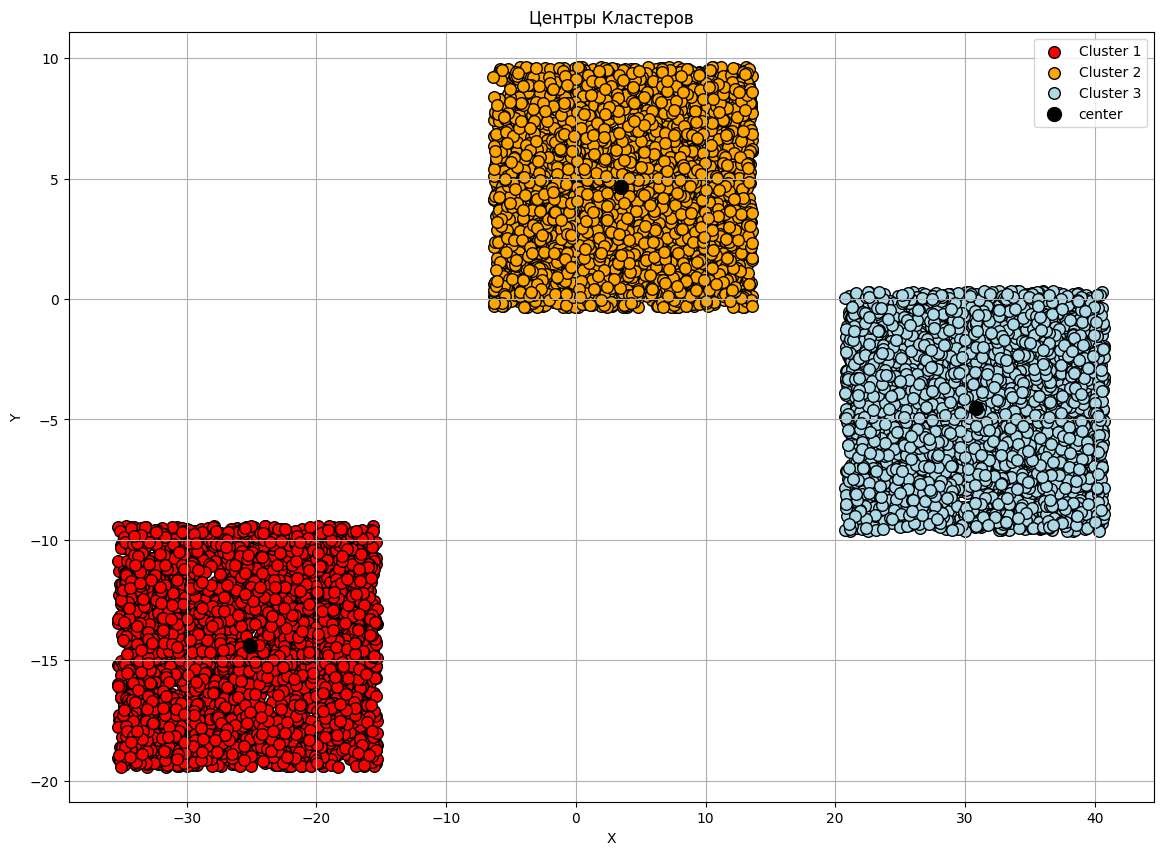

In [91]:
centers = pd.DataFrame([[x_cent_1, y_cent_1], [x_cent_2, y_cent_2], [x_cent_3, y_cent_3]], columns=['X', 'Y'])

point_distribution_with_cluster(dfs=(cluster1_df, cluster2_df, cluster3_df), colors=('red', 'orange', 'lightblue'),
                                title='Центры Кластеров')
plt.scatter(centers['X'], centers['Y'], color='black', label='center', s=100)
plt.legend()

plt.show()

## 4

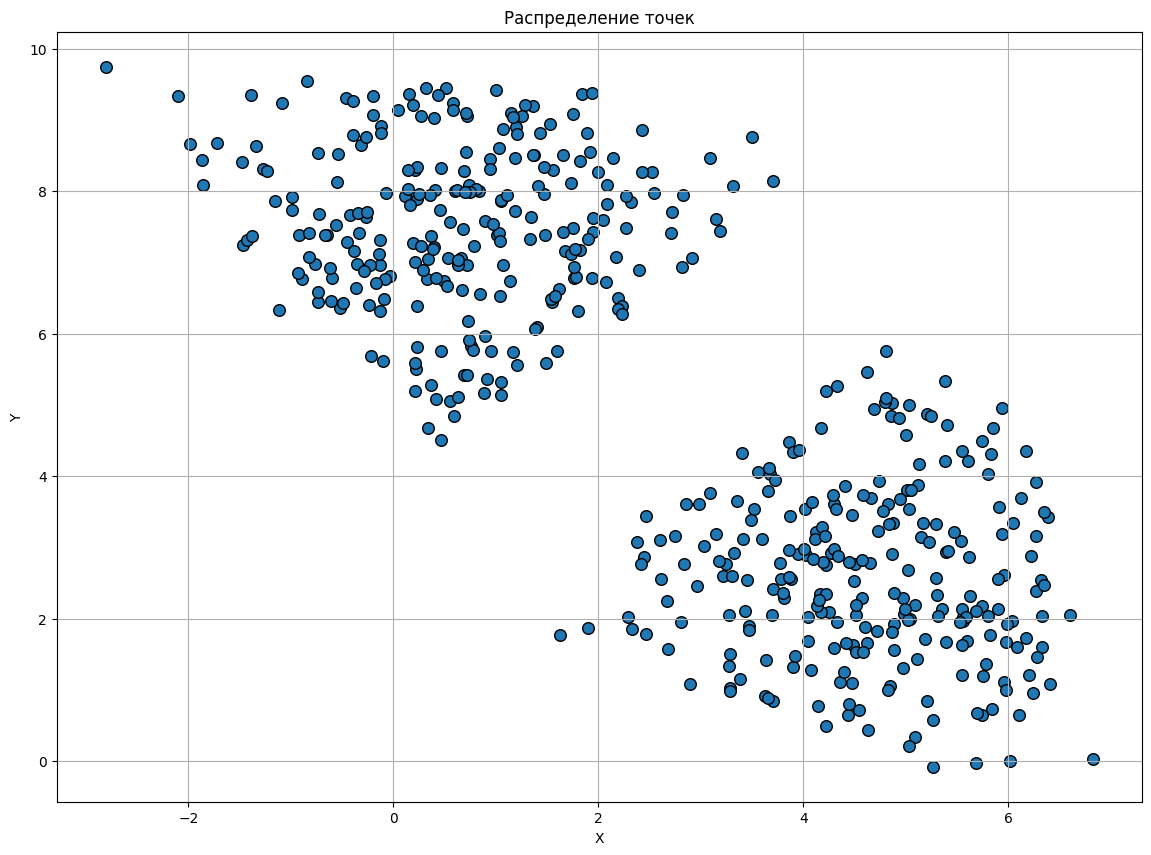

In [104]:
data = pd.read_excel('4.xlsx')
df = pd.DataFrame(data)

point_distribution(df)
plt.show()

In [97]:
cluster1 = []
cluster2 = []

for dot in df.values:
    if dot[1] > dot[0] + 2:
        cluster1.append(dot)
    else:
        cluster2.append(dot)

cluster1_df = pd.DataFrame(cluster1, columns=['X', 'Y'])
cluster2_df = pd.DataFrame(cluster2, columns=['X', 'Y'])

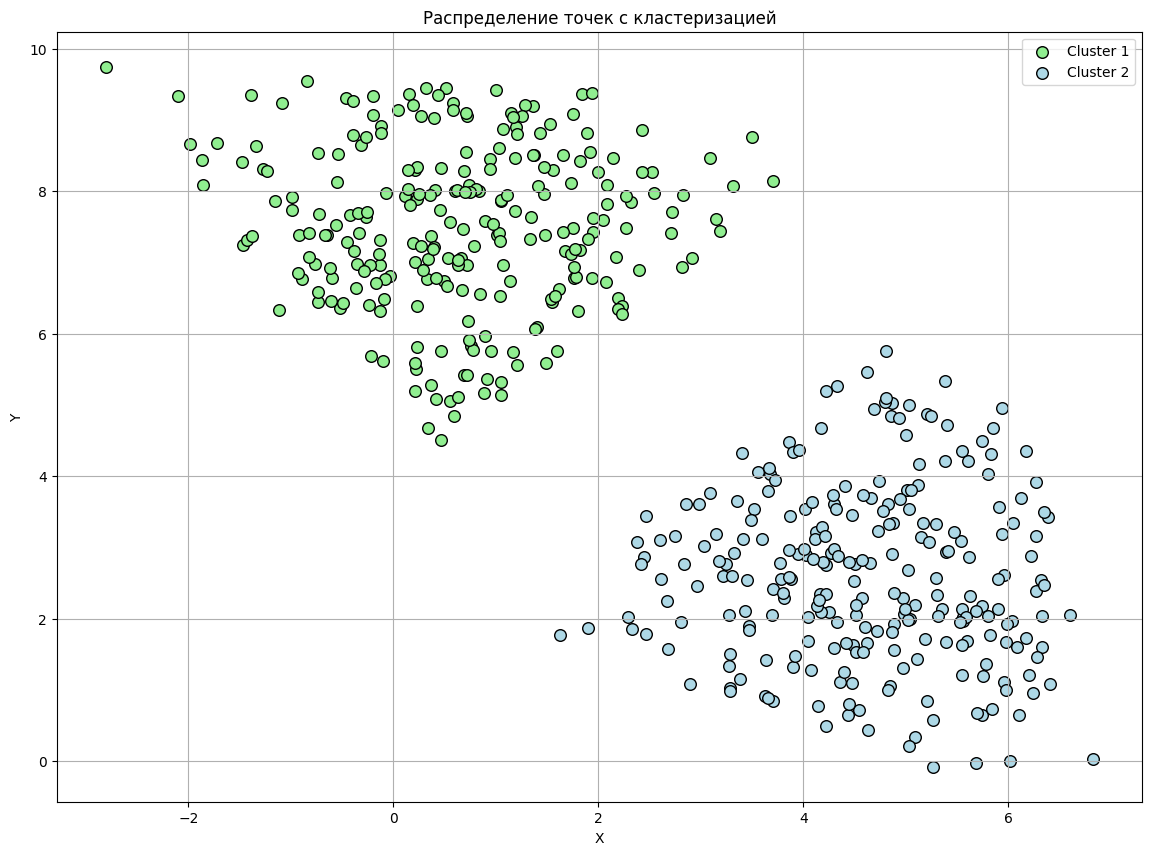

In [96]:
point_distribution_with_cluster(dfs=(cluster1_df, cluster2_df), colors=('lightgreen', 'lightblue'))
plt.show()

In [101]:
x_cent_1, y_cent_1 = find_cluster_center(cluster1, distance_manhattan)
x_cent_2, y_cent_2 = find_cluster_center(cluster2, distance_manhattan)

print("Координаты центров кластеров")
print("Кластер 1:")
print_coord(x_cent_1, y_cent_1)
print("Кластер 2:")
print_coord(x_cent_2, y_cent_2)

Координаты центров кластеров
Кластер 1:
X - 0.67779
Y - 7.46832
Кластер 2:
X - 4.49929
Y - 2.52481


In [102]:
x_mid = ((x_cent_1 + x_cent_2) / 2) * 1000
y_mid = ((y_cent_1 + y_cent_2) / 2) * 1000

print("Усредненное центров кластеров * 1000:")
print_coord(x_mid, y_mid)

Усредненное центров кластеров * 1000:
X - 2588.53992
Y - 4996.56750


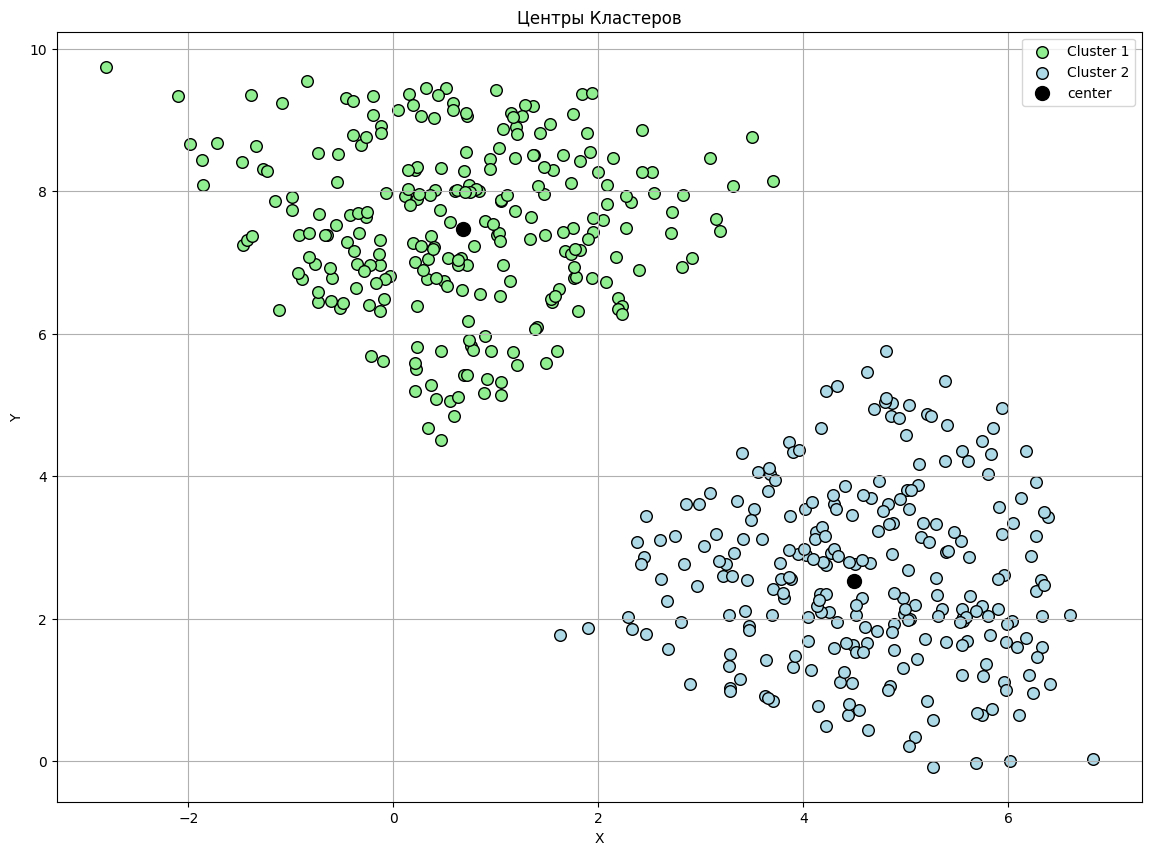

In [103]:
centers = pd.DataFrame([[x_cent_1, y_cent_1], [x_cent_2, y_cent_2]], columns=['X', 'Y'])

point_distribution_with_cluster(dfs=(cluster1_df, cluster2_df), colors=('lightgreen', 'lightblue'),
                                title='Центры Кластеров')
plt.scatter(centers['X'], centers['Y'], color='black', label='center', s=100)
plt.legend()

plt.show()

## 5

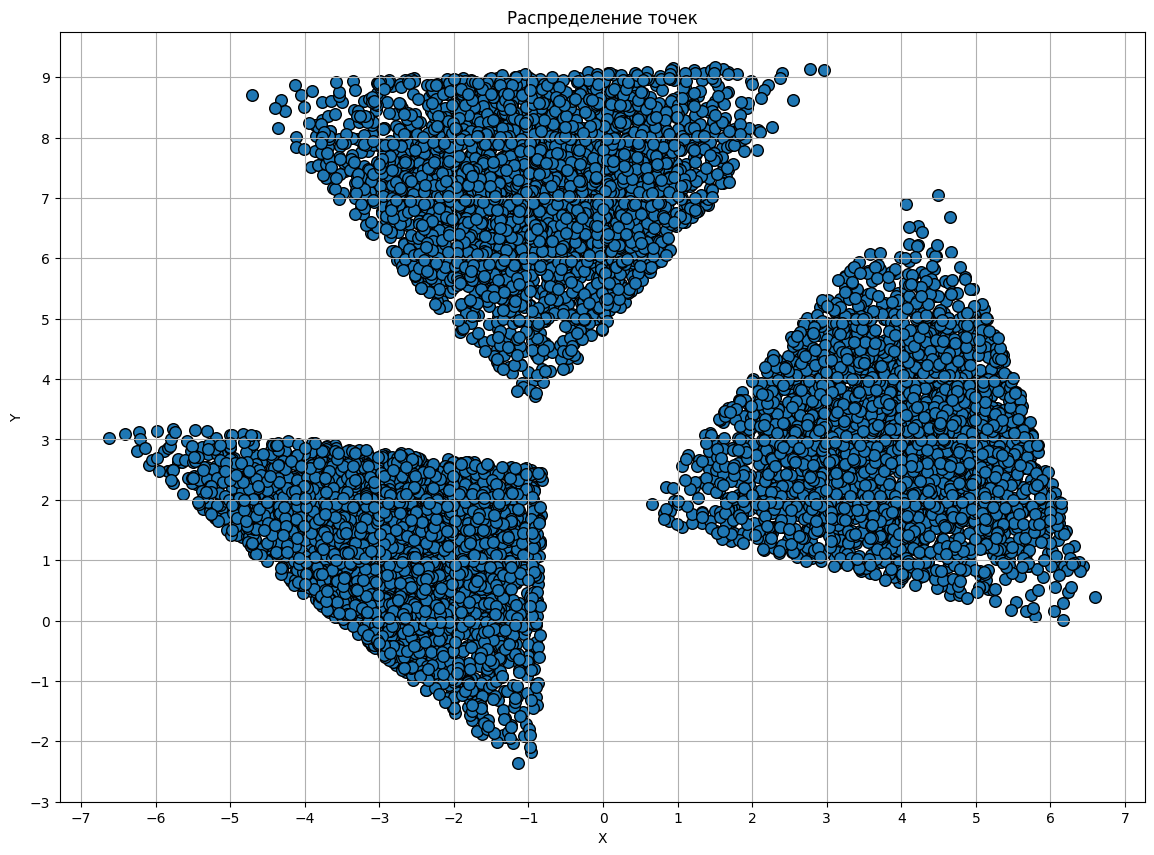

In [107]:
data = pd.read_excel('5.xlsx')
df = pd.DataFrame(data)

point_distribution(df)
plt.xticks(np.arange(-7, 8, 1))
plt.yticks(np.arange(-3, 10, 1))
plt.show()

In [109]:
cluster1 = []
cluster2 = []
cluster3 = []

for dot in df.values:
    if dot[1] > 1.25 * dot[0] + 3 and dot[1] > -1.2 * dot[0] + 1.8:
        cluster1.append(dot)
    elif dot[1] < 1.25 * dot[0] + 3 and dot[0] > 0:
        cluster2.append(dot)
    else:
        cluster3.append(dot)

cluster1_df = pd.DataFrame(cluster1, columns=['X', 'Y'])
cluster2_df = pd.DataFrame(cluster2, columns=['X', 'Y'])
cluster3_df = pd.DataFrame(cluster3, columns=['X', 'Y'])

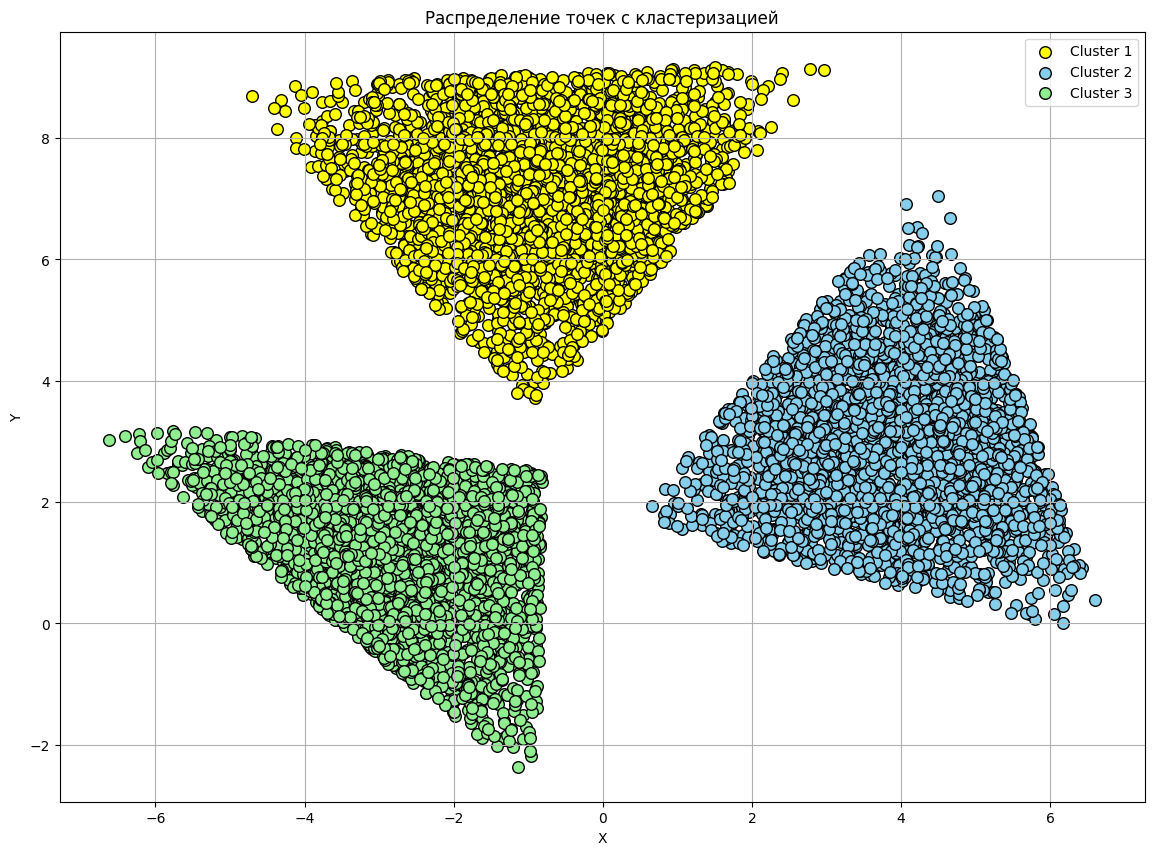

In [129]:
point_distribution_with_cluster(dfs=(cluster1_df, cluster2_df, cluster3_df), colors=('yellow', 'skyblue', 'lightgreen'))
plt.show()

In [130]:
x_cent_1, y_cent_1 = find_cluster_center(cluster1, distance_euclid)
x_cent_2, y_cent_2 = find_cluster_center(cluster2, distance_euclid)
x_cent_3, y_cent_3 = find_cluster_center(cluster3, distance_euclid)

print("Координаты центров кластеров")
print("Кластер 1:")
print_coord(x_cent_1, y_cent_1)
print("Кластер 2:")
print_coord(x_cent_2, y_cent_2)
print("Кластер 3:")
print_coord(x_cent_3, y_cent_3)

Координаты центров кластеров
Кластер 1:
X - -0.92395
Y - 7.11986
Кластер 2:
X - 3.85858
Y - 2.90717
Кластер 3:
X - -2.74967
Y - 1.14306


In [131]:
x_mid = ((x_cent_1 + x_cent_2 + x_cent_3) / 3) * 1000
y_mid = ((y_cent_1 + y_cent_2 + x_cent_3) / 3) * 1000

print("Усредненное центров кластеров * 1000:")
print_coord(x_mid, y_mid)

Усредненное центров кластеров * 1000:
X - 61.65219
Y - 2425.78443


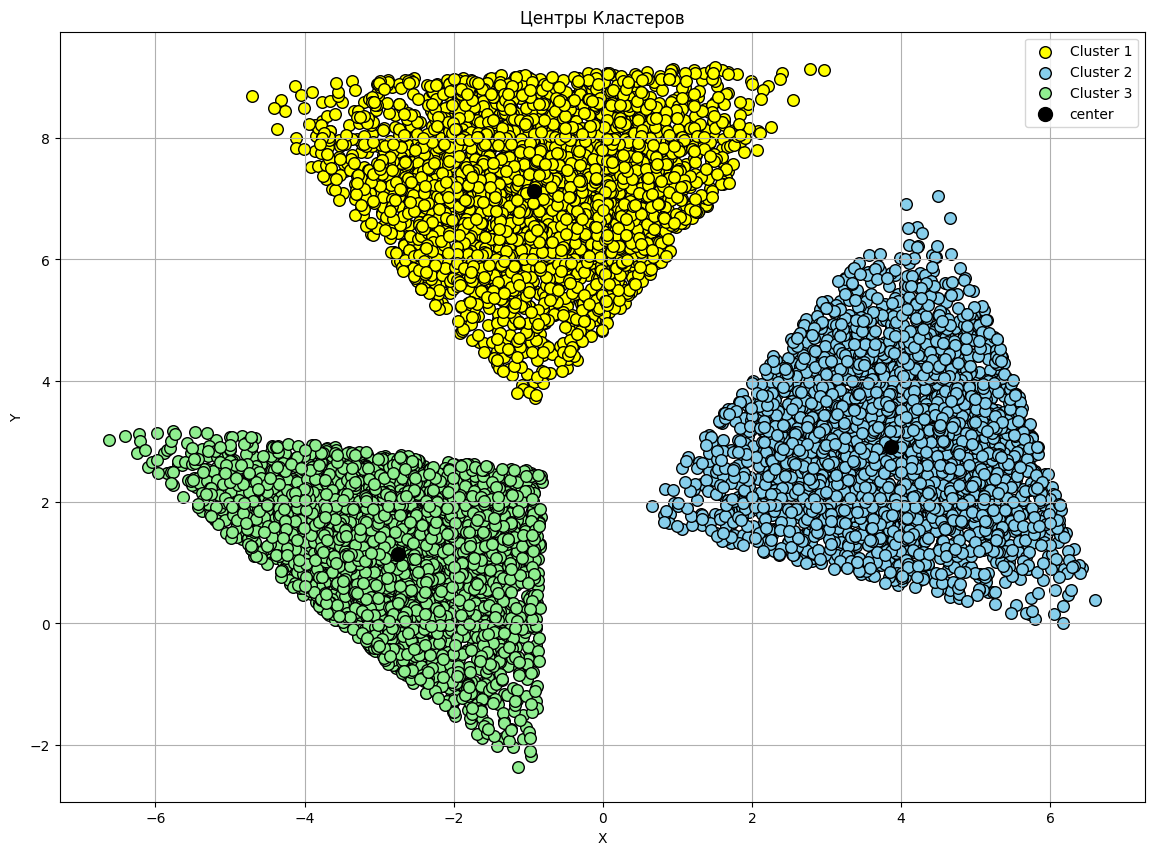

In [132]:
centers = pd.DataFrame([[x_cent_1, y_cent_1], [x_cent_2, y_cent_2], [x_cent_3, y_cent_3]], columns=['X', 'Y'])

point_distribution_with_cluster(dfs=(cluster1_df, cluster2_df, cluster3_df), colors=('yellow', 'skyblue', 'lightgreen'),
                                title='Центры Кластеров')
plt.scatter(centers['X'], centers['Y'], color='black', label='center', s=100)
plt.legend()

plt.show()

# Кластеризация (0.75 за каждый алгоритм на всех данных)

На предложенных распределениях данных проверьте предложенные алгоритмы. Постройте графики кластеризации для каждой пары алгоритм-данные, разные кластеры покрасьте разным цветом. Воспользуйтесь sklearn реализациями. Параметры кластеризации для разных алгоритмов подберите такие, чтобы алгоритмы можно было сравнивать (по возможности одинаковое количество кластеров и т.д.)

In [133]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

In [ ]:
two_means =
dbscan =

clustering_algorithms = (
        ("MiniBatch\nKMeans", two_means),
        ("DBSCAN", dbscan),
    )

In [ ]:
np.random.seed(0)

# ============
# Generate datasets. We choose the size big enough to see the scalability
# of the algorithms, but not too big to avoid too long running times
# ============
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = np.random.rand(n_samples, 2), None

# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# blobs with varied variances
varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

# ============
# Set up cluster parameters
# ============
plt.figure(figsize=(9 * 2 + 3, 13))
plt.subplots_adjust(
    left=0.02, right=0.98, bottom=0.001, top=0.95, wspace=0.05, hspace=0.01
)

plot_num = 1

default_base = {
    "quantile": 0.3,
    "eps": 0.3,
    "damping": 0.9,
    "preference": -200,
    "n_neighbors": 10,
    "n_clusters": 3,
    "min_samples": 20,
    "xi": 0.05,
    "min_cluster_size": 0.1,
}

datasets = [
    (
        noisy_circles,
        {
            "damping": 0.77,
            "preference": -240,
            "quantile": 0.2,
            "n_clusters": 2,
            "min_samples": 20,
            "xi": 0.25,
        },
    ),
    (noisy_moons, {"damping": 0.75, "preference": -220, "n_clusters": 2}),
    (
        varied,
        {
            "eps": 0.18,
            "n_neighbors": 2,
            "min_samples": 5,
            "xi": 0.035,
            "min_cluster_size": 0.2,
        },
    ),
    (
        aniso,
        {
            "eps": 0.15,
            "n_neighbors": 2,
            "min_samples": 20,
            "xi": 0.1,
            "min_cluster_size": 0.2,
        },
    ),
    (blobs, {}),
    (no_structure, {}),
]

for i_dataset, (dataset, algo_params) in enumerate(datasets):
    # update parameters with dataset-specific values
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset

    # normalize dataset for easier parameter selection
    X = StandardScaler().fit_transform(X)

    # estimate bandwidth for mean shift
    bandwidth = cluster.estimate_bandwidth(X, quantile=params["quantile"])

    # connectivity matrix for structured Ward
    connectivity = kneighbors_graph(
        X, n_neighbors=params["n_neighbors"], include_self=False
    )
    # make connectivity symmetric
    connectivity = 0.5 * (connectivity + connectivity.T)

    for name, algorithm in clustering_algorithms:
        t0 = time.time()